# SafeCrowd AI — ShanghaiTech Part A Preprocessing
### Made for Team SafeCrowd AI | Run cells one by one

---
**What this notebook does:**
1. Mounts your Google Drive
2. Reads ShanghaiTech Part A dataset (images + .mat ground truth files)
3. Converts dot annotations → Gaussian density maps
4. Resizes all images to 512x512
5. Saves processed data back to your Drive

> ⚠️ **Before running:** Upload `ShanghaiTech.zip` to your Google Drive inside a folder called `SafeCrowd-Data/raw/`

## Cell 1 — Install Required Libraries

In [1]:
!pip install scipy numpy pillow h5py matplotlib -q
print('✅ Libraries installed successfully')

✅ Libraries installed successfully


## Cell 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted at /content/drive')

Mounted at /content/drive
✅ Google Drive mounted at /content/drive


## Cell 3 — Set Paths (Check these before running!)

In [3]:
import os

# ─── PATHS — change only if your folder names are different ───
DRIVE_BASE       = '/content/drive/MyDrive/SafeCrowd-Data'
ZIP_PATH         = os.path.join(DRIVE_BASE, 'raw', 'ShanghaiTech.zip')
EXTRACT_PATH     = '/content/ShanghaiTech'          # temporary, inside Colab
OUTPUT_DRIVE     = os.path.join(DRIVE_BASE, 'processed_partA')

# Create output folders
for split in ['train', 'test']:
    os.makedirs(os.path.join(OUTPUT_DRIVE, split, 'images'),       exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DRIVE, split, 'density_maps'), exist_ok=True)

print('✅ Output folders created:')
print(f'   {OUTPUT_DRIVE}/train/images/')
print(f'   {OUTPUT_DRIVE}/train/density_maps/')
print(f'   {OUTPUT_DRIVE}/test/images/')
print(f'   {OUTPUT_DRIVE}/test/density_maps/')

# Check zip exists
if os.path.exists(ZIP_PATH):
    print(f'\n✅ Dataset zip found at: {ZIP_PATH}')
else:
    print(f'\n❌ ZIP NOT FOUND at: {ZIP_PATH}')
    print('   Please upload ShanghaiTech.zip to Drive → SafeCrowd-Data/raw/')

✅ Output folders created:
   /content/drive/MyDrive/SafeCrowd-Data/processed_partA/train/images/
   /content/drive/MyDrive/SafeCrowd-Data/processed_partA/train/density_maps/
   /content/drive/MyDrive/SafeCrowd-Data/processed_partA/test/images/
   /content/drive/MyDrive/SafeCrowd-Data/processed_partA/test/density_maps/

✅ Dataset zip found at: /content/drive/MyDrive/SafeCrowd-Data/raw/ShanghaiTech.zip


## Cell 4 — Extract Dataset

In [4]:
import zipfile

print('Extracting dataset... (this may take 2-3 minutes)')
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_PATH)

# Verify extraction
part_a_train = os.path.join(EXTRACT_PATH, 'ShanghaiTech', 'part_A', 'train_data')
part_a_test  = os.path.join(EXTRACT_PATH, 'ShanghaiTech', 'part_A', 'test_data')

train_imgs = len(os.listdir(os.path.join(part_a_train, 'images')))
test_imgs  = len(os.listdir(os.path.join(part_a_test,  'images')))

print(f'\n✅ Extraction complete!')
print(f'   Train images found : {train_imgs}  (expected: 300)')
print(f'   Test  images found : {test_imgs}   (expected: 182)')

Extracting dataset... (this may take 2-3 minutes)

✅ Extraction complete!
   Train images found : 300  (expected: 300)
   Test  images found : 182   (expected: 182)


## Cell 5 — Core Functions (Density Map Generation)

In [5]:
import numpy as np
import scipy.io as sio
from scipy.ndimage import gaussian_filter
from PIL import Image

TARGET_SIZE = (512, 512)   # all images resized to this
SIGMA       = 15           # Gaussian spread — standard for Part A dense crowds


def load_gt_from_mat(mat_path):
    """
    Reads .mat file and returns array of (x, y) head positions.
    ShanghaiTech stores annotations under key 'image_info'.
    """
    mat  = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    info = mat['image_info']
    ann  = info.location   # shape: (N, 2)  — N people, columns = [x, y]
    return ann


def generate_density_map(image_shape, annotations, sigma=SIGMA):
    """
    Creates a density map from dot annotations.
    - image_shape : (H, W) of the ORIGINAL image
    - annotations : (N, 2) array of [x, y] head positions
    Returns density map of same shape as image_shape.
    """
    h, w   = image_shape
    density = np.zeros((h, w), dtype=np.float32)

    for ann in annotations:
        x, y = int(min(ann[0], w - 1)), int(min(ann[1], h - 1))
        if 0 <= x < w and 0 <= y < h:
            density[y, x] += 1.0

    density = gaussian_filter(density, sigma=sigma)
    return density


def scale_density_map(density, orig_shape, target_shape):
    """
    When we resize image from orig_shape → target_shape,
    we must scale the density map too AND fix the count.
    """
    orig_h, orig_w     = orig_shape
    target_h, target_w = target_shape

    img_density = Image.fromarray(density)
    img_density = img_density.resize((target_w, target_h), Image.BILINEAR)
    scaled      = np.array(img_density)

    # Fix count: multiply by area ratio so sum stays correct
    area_ratio = (target_h * target_w) / (orig_h * orig_w)
    scaled     = scaled * area_ratio
    return scaled.astype(np.float32)


print('✅ Functions defined successfully')
print(f'   Target image size : {TARGET_SIZE}')
print(f'   Gaussian sigma    : {SIGMA}')

✅ Functions defined successfully
   Target image size : (512, 512)
   Gaussian sigma    : 15


## Cell 6 — Process Train Set (300 images)

In [7]:
import time

def process_split(split_name, data_folder, output_folder):
    img_dir = os.path.join(data_folder, 'images')
    gt_dir  = os.path.join(data_folder, 'ground-truth')
    out_img  = os.path.join(output_folder, split_name, 'images')
    out_dmap = os.path.join(output_folder, split_name, 'density_maps')

    img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
    total     = len(img_files)
    errors    = []

    print(f'\nProcessing {split_name} set — {total} images')
    print('─' * 50)

    for i, img_name in enumerate(img_files):
        try:
            img_id   = img_name.replace('.jpg', '')          # e.g. IMG_1
            mat_name = f'GT_{img_id}.mat'

            img_path = os.path.join(img_dir, img_name)
            mat_path = os.path.join(gt_dir,  mat_name)

            # Load image
            img      = Image.open(img_path).convert('RGB')
            orig_w, orig_h = img.size                        # PIL gives (W, H)

            # Load ground truth annotations
            annotations = load_gt_from_mat(mat_path)
            gt_count    = len(annotations)

            # Generate density map at original resolution
            density_orig = generate_density_map((orig_h, orig_w), annotations)

            # Resize image
            img_resized  = img.resize(TARGET_SIZE, Image.BILINEAR)

            # Scale density map to match resized image
            density_scaled = scale_density_map(
                density_orig,
                (orig_h, orig_w),
                (TARGET_SIZE[1], TARGET_SIZE[0])
            )

            # Verify count is preserved
            pred_count = density_scaled.sum()

            # Save image as .jpg
            img_resized.save(os.path.join(out_img, img_name))

            # Save density map as .npy
            npy_name = img_name.replace('.jpg', '.npy')
            np.save(os.path.join(out_dmap, npy_name), density_scaled)

            if (i + 1) % 50 == 0 or (i + 1) == total:
                print(f'  [{i+1:3d}/{total}] {img_name} | '
                      f'GT count: {gt_count:4d} | '
                      f'Density sum: {pred_count:.1f}')

        except Exception as e:
            errors.append((img_name, str(e)))
            print(f'  ❌ Error on {img_name}: {e}')

    print(f'\n✅ {split_name} set done!')
    print(f'   Processed : {total - len(errors)}/{total}')
    if errors:
        print(f'   Errors    : {len(errors)} — {errors}')
    return errors


# ── Run Train ──
t0 = time.time()
train_errors = process_split(
    split_name  = 'train',
    data_folder = part_a_train,
    output_folder = OUTPUT_DRIVE
)
print(f'\nTime taken: {(time.time()-t0)/60:.1f} minutes')


Processing train set — 300 images
──────────────────────────────────────────────────
  [ 50/300] IMG_143.jpg | GT count: 1296 | Density sum: 232.0
  [100/300] IMG_189.jpg | GT count:  498 | Density sum: 911.6
  [150/300] IMG_233.jpg | GT count:  312 | Density sum: 34.7
  [200/300] IMG_279.jpg | GT count:  166 | Density sum: 554.2
  [250/300] IMG_53.jpg | GT count:  257 | Density sum: 43.5
  [300/300] IMG_99.jpg | GT count:  431 | Density sum: 59.7

✅ train set done!
   Processed : 300/300

Time taken: 0.6 minutes


## Cell 7 — Process Test Set (182 images)

In [8]:
t0 = time.time()
test_errors = process_split(
    split_name    = 'test',
    data_folder   = part_a_test,
    output_folder = OUTPUT_DRIVE
)
print(f'\nTime taken: {(time.time()-t0)/60:.1f} minutes')


Processing test set — 182 images
──────────────────────────────────────────────────
  [ 50/182] IMG_143.jpg | GT count:  357 | Density sum: 434.6
  [100/182] IMG_24.jpg | GT count:  553 | Density sum: 90.4
  [150/182] IMG_7.jpg | GT count:  568 | Density sum: 79.8
  [182/182] IMG_99.jpg | GT count:  242 | Density sum: 176.2

✅ test set done!
   Processed : 182/182

Time taken: 0.4 minutes


## Cell 8 — Verify Everything & Final Summary

══════════════════════════════════════════════════
         PREPROCESSING COMPLETE — SUMMARY
══════════════════════════════════════════════════
  Train images      : 300  (expected 300)
  Train density maps: 300  (expected 300)
  Test  images      : 182  (expected 182)
  Test  density maps: 182  (expected 182)
  Image size        : 512 x 512
  Saved to Drive    : /content/drive/MyDrive/SafeCrowd-Data/processed_partA
══════════════════════════════════════════════════


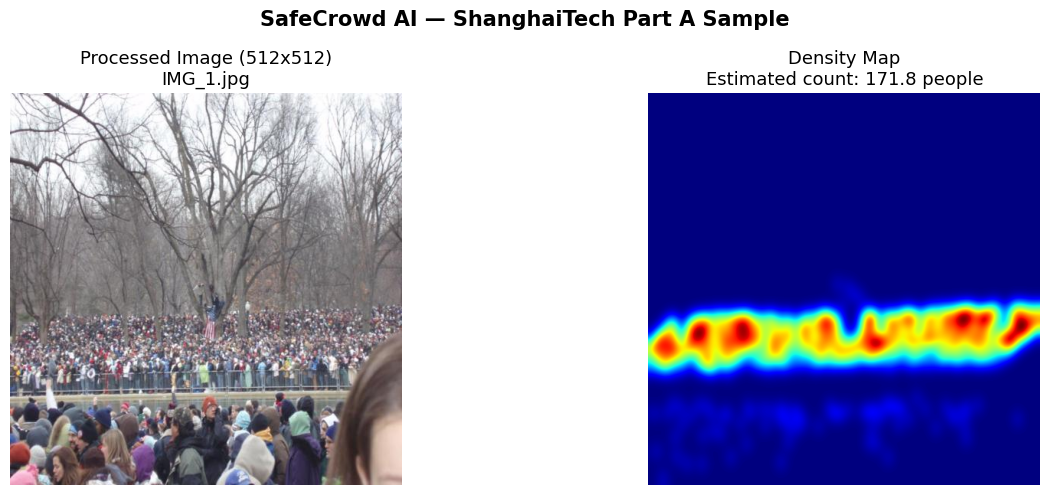


✅ Visual check passed! Share the screenshot of this with Adibaa.


In [9]:
import matplotlib.pyplot as plt

# Count output files
train_img_count  = len(os.listdir(os.path.join(OUTPUT_DRIVE, 'train', 'images')))
train_dmap_count = len(os.listdir(os.path.join(OUTPUT_DRIVE, 'train', 'density_maps')))
test_img_count   = len(os.listdir(os.path.join(OUTPUT_DRIVE, 'test',  'images')))
test_dmap_count  = len(os.listdir(os.path.join(OUTPUT_DRIVE, 'test',  'density_maps')))

print('═' * 50)
print('         PREPROCESSING COMPLETE — SUMMARY')
print('═' * 50)
print(f'  Train images      : {train_img_count}  (expected 300)')
print(f'  Train density maps: {train_dmap_count}  (expected 300)')
print(f'  Test  images      : {test_img_count}  (expected 182)')
print(f'  Test  density maps: {test_dmap_count}  (expected 182)')
print(f'  Image size        : 512 x 512')
print(f'  Saved to Drive    : {OUTPUT_DRIVE}')
print('═' * 50)

# Visual check — show 1 sample image + its density map
sample_img_path  = os.path.join(OUTPUT_DRIVE, 'train', 'images', 'IMG_1.jpg')
sample_dmap_path = os.path.join(OUTPUT_DRIVE, 'train', 'density_maps', 'IMG_1.npy')

if os.path.exists(sample_img_path):
    sample_img  = np.array(Image.open(sample_img_path))
    sample_dmap = np.load(sample_dmap_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(sample_img)
    axes[0].set_title(f'Processed Image (512x512)\nIMG_1.jpg', fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(sample_dmap, cmap='jet')
    axes[1].set_title(f'Density Map\nEstimated count: {sample_dmap.sum():.1f} people', fontsize=13)
    axes[1].axis('off')

    plt.suptitle('SafeCrowd AI — ShanghaiTech Part A Sample', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('\n✅ Visual check passed! Share the screenshot of this with Adibaa.')
else:
    print('\n⚠️  Sample image not found for visual check.')

## Cell 9 — Push Preprocessing Script to GitHub

**Steps for Ashlesha:**
1. Go to the team GitHub repo
2. Create folder: `preprocessing/`
3. Upload this notebook as `SafeCrowd_PartA_Preprocessing.ipynb`
4. Add a `README.md` inside `preprocessing/` with the text below

```markdown
# Preprocessing — ShanghaiTech Part A

Run `SafeCrowd_PartA_Preprocessing.ipynb` in Google Colab.

**Before running:**
- Upload ShanghaiTech.zip to Google Drive at: `SafeCrowd-Data/raw/ShanghaiTech.zip`

**Output (saved to shared Drive):**
- `SafeCrowd-Data/processed_partA/train/images/` — 300 images (512x512)
- `SafeCrowd-Data/processed_partA/train/density_maps/` — 300 .npy files
- `SafeCrowd-Data/processed_partA/test/images/` — 182 images (512x512)
- `SafeCrowd-Data/processed_partA/test/density_maps/` — 182 .npy files

**Processed data Drive link:** [Add link here after upload]
```